# Image Similarity 
The purpose of this notebook is to try out google's pose landmarker's pose embedding abilities and see if I can create a function that takes in an image and output other images with pose's similar to it


Face 
0 - nose
1 - left eye (inner)
2 - left eye
3 - left eye (outer)
4 - right eye (inner)
5 - right eye
6 - right eye (outer)
7 - left ear
8 - right ear
9 - mouth (left)
10 - mouth (right)

Torso 
11 - left shoulder
12 - right shoulder
13 - left elbow
14 - right elbow
15 - left wrist
16 - right wrist
17 - left pinky
18 - right pinky
19 - left index
20 - right index
21 - left thumb
22 - right thumb

Legs 
23 - left hip
24 - right hip
25 - left knee
26 - right knee
27 - left ankle
28 - right ankle
29 - left heel
30 - right heel
31 - left foot index
32 - right foot index

In [4]:
# Imports 
import numpy as np
from mediapipe.tasks.python.vision import drawing_utils
from mediapipe.tasks.python.vision import drawing_styles
from mediapipe.tasks.python import vision
import mediapipe as mp
from mediapipe.tasks import python
import matplotlib.pyplot as plt
import pandas as pd 
import pickle as pkl
from tqdm import tqdm
import os 
from PIL import Image


In [13]:
path = "C:/Users/leahz/Documents/ATC/pose-project/data"

In [8]:
features = {
    "head" : [(8,7), (10,9), (8,10), (7,9)],
    "torso" : [(12,11), (24,23), (12,24), (11,23)],
    "left-leg": [(24,26), (26,28)],
    "right-leg": [(23,25), (25,27)],
    "legs":[(24,23), (26,25), (28,27), (30,32), (29,31)],
    "left-arm": [(12,14), (14,16)], 
    "right-arm": [(11,13), (13,15)],
    "full-body":[(0,24), (0,23), (0,12), (0,11)]
}

## Visualization

In [71]:
def draw_landmarks_on_image(rgb_image, detection_result):
  pose_landmarks_list = detection_result.pose_landmarks
  annotated_image = np.copy(rgb_image)

  pose_landmark_style = drawing_styles.get_default_pose_landmarks_style()
  pose_connection_style = drawing_utils.DrawingSpec(color=(0, 255, 0), thickness=2)

  for pose_landmarks in pose_landmarks_list:
    drawing_utils.draw_landmarks(
        image=annotated_image,
        landmark_list=pose_landmarks,
        connections=vision.PoseLandmarksConnections.POSE_LANDMARKS,
        landmark_drawing_spec=pose_landmark_style,
        connection_drawing_spec=pose_connection_style)

  return annotated_image

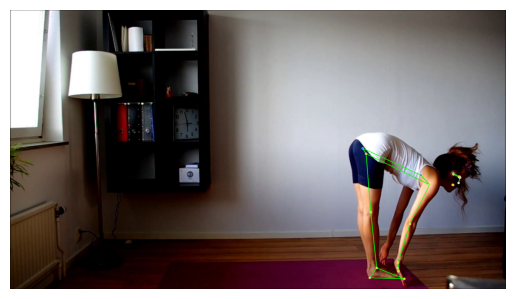

In [72]:
# STEP 2: Create an PoseLandmarker object.
base_options = python.BaseOptions(model_asset_path=f'{path}/pose_landmarker_full.task')
options = vision.PoseLandmarkerOptions(
    base_options=base_options,
    output_segmentation_masks=True)
detector = vision.PoseLandmarker.create_from_options(options)


# STEP 3: Load the input image.
image = mp.Image.create_from_file(f"{path}/mpii_human_pose_v1/images/000004812.jpg")

# STEP 4: Detect pose landmarks from the input image.
detection_result = detector.detect(image)


# STEP 5: Process the detection result. In this case, visualize it.
annotated_image = draw_landmarks_on_image(image.numpy_view(), detection_result)


plt.imshow(annotated_image)
plt.axis('off')
plt.show()

In [73]:
detection_result.pose_world_landmarks[0]

[Landmark(x=0.6090859174728394, y=0.263674795627594, z=-0.012665720656514168, visibility=0.9993300437927246, presence=0.9995297193527222, name=None),
 Landmark(x=0.6290792226791382, y=0.22555696964263916, z=-0.00633199280127883, visibility=0.999349057674408, presence=0.9993002414703369, name=None),
 Landmark(x=0.6292476654052734, y=0.22611016035079956, z=-0.005539468955248594, visibility=0.9995766282081604, presence=0.9993000030517578, name=None),
 Landmark(x=0.6297169327735901, y=0.2259865403175354, z=-0.005637429188936949, visibility=0.9996262788772583, presence=0.9992290735244751, name=None),
 Landmark(x=0.62435382604599, y=0.22564661502838135, z=-0.03436931222677231, visibility=0.9994422793388367, presence=0.999200165271759, name=None),
 Landmark(x=0.6249830722808838, y=0.22643287479877472, z=-0.03523759916424751, visibility=0.9994864463806152, presence=0.9990864992141724, name=None),
 Landmark(x=0.6264437437057495, y=0.22626642882823944, z=-0.03444526717066765, visibility=0.999429

# Creating the Data Structure

In [74]:
# data strcture guide
# pose_embedding = {
#     "features": {
#         "head": {
#             "vectors": [v1, v2, v3, v4],        # (N, 3)
#             "vector_visibility": [vv1, vv2, vv3, vv4],
#             "feature_visibility": float
#         },
#         "torso": {
#             "vectors": [...],
#             "vector_visibility": [...],
#             "feature_visibility": float
#         }
#     }
# }

In [19]:
def normalize_vector(v):
    norm = np.linalg.norm(v)
    if norm < 1e-8: 
        return np.zeros(3)
    return v/norm

In [20]:
def calculate_body_frame(points):
    mid_shoulders = (points[11] + points[12]) / 2
    mid_hips = (points[23] + points[24]) / 2

    up = mid_shoulders - mid_hips
    up = normalize_vector(up)

    right = points[12] - points[11]
    right = normalize_vector(up)

    forward = np.cross(right, up)
    forward = normalize_vector(forward)
    return right, up, forward

In [77]:
def to_body_frame(v, right, up, forward):
    return np.array([np.dot(v, right), np.dot(v, up), np.dot(v, forward)])

In [15]:
def convert_landmark_to_embed(points, visibility): 
    Right, Up, Forward = calculate_body_frame(points)
    embedding_result = {}
    for name, pairs in features.items():
        current = {}
        vectors = []
        vector_visibility = []
        for p1,p2 in pairs:
            v = points[p2]-points[p1]
            v = normalize_vector(v)
            # Rotate frame so image rotations don't matter
            # v = np.array([v.dot(Right), v.dot(Up), v.dot(Forward)])
            # v = v / np.linalg.norm(v) 
            vectors.append(v)
            vector_visibility.append(min(visibility[p1], visibility[p2]))
        fv = sum(vector_visibility)/len(vector_visibility)
        current["vectors"]=vectors
        current["vector_visibility"]=vector_visibility
        current["feature_visibility"]=fv
        embedding_result[name] = current 
    return embedding_result
    
    

# Data Processing

Pipeline 
1. apply model and save all data to pkl 
2. embed saved data into new dataset 
3. see if the distance calculation works

In [16]:
df = pd.read_csv(f"{path}/sample_data.csv")

In [24]:
def compute_pose_bbox(points, visibility, image_width, image_height, vis_threshold=0.2, padding=0.2):
    """Compute a padded pixel-space bbox from normalized pose landmarks."""
    visible_idx = visibility >= vis_threshold
    pts_xy = points[visible_idx, :2] if np.any(visible_idx) else points[:, :2]

    x = pts_xy[:, 0] * image_width
    y = pts_xy[:, 1] * image_height

    x1, y1 = np.min(x), np.min(y)
    x2, y2 = np.max(x), np.max(y)

    w = max(x2 - x1, 1.0)
    h = max(y2 - y1, 1.0)
    pad_x = w * padding
    pad_y = h * padding

    x1 = int(max(0, np.floor(x1 - pad_x)))
    y1 = int(max(0, np.floor(y1 - pad_y)))
    x2 = int(min(image_width, np.ceil(x2 + pad_x)))
    y2 = int(min(image_height, np.ceil(y2 + pad_y)))

    return [x1, y1, x2, y2]


def save_data_processed(filepaths, save_file, vis_threshold=0.2, bbox_padding=0.2):
    base_options = python.BaseOptions(model_asset_path=f'{path}/pose_landmarker_full.task')
    options = vision.PoseLandmarkerOptions(
        base_options=base_options,
        output_segmentation_masks=True)
    detector = vision.PoseLandmarker.create_from_options(options)

    dataset = {}

    for file in tqdm(filepaths):
        image = mp.Image.create_from_file(f"{path}/mpii_human_pose_v1/images/{file}")
        detection_result = detector.detect(image)
        if not detection_result.pose_world_landmarks or not detection_result.pose_landmarks:
            continue

        world_landmarks = detection_result.pose_world_landmarks[0]
        image_landmarks = detection_result.pose_landmarks[0]

        points = np.array([[lm.x, lm.y, lm.z] for lm in world_landmarks])
        visibility = np.array([lm.visibility for lm in world_landmarks])

        # Pose bbox must come from image-space normalized landmarks, not world coordinates.
        image_points = np.array([[lm.x, lm.y, lm.z] for lm in image_landmarks])
        image_visibility = np.array([lm.visibility for lm in image_landmarks])

        embedding = convert_landmark_to_embed(points, visibility)

        img_h, img_w = image.numpy_view().shape[:2]
        bbox_xyxy = compute_pose_bbox(
            image_points,
            image_visibility,
            image_width=img_w,
            image_height=img_h,
            vis_threshold=vis_threshold,
            padding=bbox_padding,
        )

        dataset[file] = {
            "points": points,
            "visibility": visibility,
            "embedding": embedding,
            "bbox_xyxy": bbox_xyxy,
            "image_size": [img_w, img_h],
        }

    with open(f"{path}/{save_file}", "wb") as f:
        pkl.dump(dataset, f)

In [25]:
save_data_processed(df['img_paths'], "small_embeded_dataset.pkl")

100%|██████████| 1000/1000 [01:21<00:00, 12.30it/s]


# Distance Calculation

In [26]:
with open(f"{path}/small_embeded_dataset.pkl", "rb") as f: 
    dataset = pkl.load(f)

In [83]:
dataset.keys()

dict_keys(['017150982.jpg', '046378060.jpg', '073795312.jpg', '059098668.jpg', '017512314.jpg', '001686287.jpg', '084262720.jpg', '029314773.jpg', '000759142.jpg', '046382973.jpg', '069628878.jpg', '051876195.jpg', '001135364.jpg', '068678897.jpg', '063007315.jpg', '030679428.jpg', '012906512.jpg', '056880035.jpg', '027568590.jpg', '036459373.jpg', '054164151.jpg', '076046461.jpg', '025376261.jpg', '073702591.jpg', '043799775.jpg', '044433517.jpg', '009284509.jpg', '028059022.jpg', '033689579.jpg', '075678922.jpg', '027253117.jpg', '083980161.jpg', '098129709.jpg', '061135303.jpg', '016284658.jpg', '047570408.jpg', '094888554.jpg', '020208431.jpg', '074608216.jpg', '058535436.jpg', '086182813.jpg', '072487051.jpg', '088480308.jpg', '069892766.jpg', '043395492.jpg', '042422201.jpg', '010621383.jpg', '067894542.jpg', '058996065.jpg', '098842099.jpg', '020728252.jpg', '020226088.jpg', '027534485.jpg', '083286601.jpg', '054760799.jpg', '000754109.jpg', '067871324.jpg', '093035118.jpg', '00

In [6]:
def pose_distance(embed1, embed2, selected_features, feature_weights=None):
    total_dist = 0.0
    total_weight = 0.0
    
    for feature in selected_features:
        if feature not in embed1 or feature not in embed2:
            continue 
        f1 = embed1[feature]
        f2 = embed2[feature]
        
        vecs1 = f1["vectors"]
        vecs2 = f2["vectors"]
        vis1 = f1["vector_visibility"]
        vis2 = f2["vector_visibility"]
        fv1 = f1["feature_visibility"]
        fv2 = f2["feature_visibility"]
        
        fw = feature_weights.get(feature, 1.0) if feature_weights else 1.0
        
        feature_dist = 0.0
        feature_weight = 0.0
        
        for i in range(len(vecs1)):
            v1 = np.array(vecs1[i])
            v2 = np.array(vecs2[i])
            
            vv = min(vis1[i], vis2[i])
            
            if vv < 0.2:
                continue
            
            d =  np.linalg.norm(v1-v2) #1-np.dot(v1,v2) #
            feature_dist += vv * d
            feature_weight += vv
        
        if feature_weight == 0:
            continue
        
        feature_dist /= feature_weight
        fvis = min(fv1, fv2)
        total_dist += fw * fvis * feature_dist
        total_weight += fw * fvis 
    
    if total_weight == 0: 
        return float("inf")
    
    return total_dist / total_weight

In [9]:
def find_nearest_neighbors(dataset, query_file, selected_features=features, k=5, feature_weights=None):
    query_embed = dataset[query_file]["embedding"]
    
    results = []
    for file, data in tqdm(dataset.items()):
        if file == query_file:
            continue
        
        dist = pose_distance(
            query_embed, 
            data["embedding"], 
            selected_features, 
            feature_weights
        )
        
        results.append((file,dist))
    
    results.sort(key= lambda x: x[1])
    return results[:k]

In [2]:
def crop_with_dataset_bbox(img, file, dataset):
    """Crop PIL image using stored bbox if available; else return original image."""
    data = dataset.get(file, {})
    bbox = data.get("bbox_xyxy")
    if not bbox or len(bbox) != 4:
        return img

    x1, y1, x2, y2 = [int(v) for v in bbox]
    x1 = max(0, min(x1, img.width - 1))
    y1 = max(0, min(y1, img.height - 1))
    x2 = max(x1 + 1, min(x2, img.width))
    y2 = max(y1 + 1, min(y2, img.height))

    return img.crop((x1, y1, x2, y2))


def show_neighbors(query_file, neighbors, image_dir, dataset, k=5):
    k = min(k, len(neighbors))
    plt.figure(figsize=(3*(k+1), 4))

    query_path = os.path.join(image_dir, query_file)
    img = Image.open(query_path)
    img = crop_with_dataset_bbox(img, query_file, dataset)

    plt.subplot(1, k + 1, 1)
    plt.imshow(img)
    plt.title("Query")
    plt.axis("off")

    for i in range(k):
        file, dist = neighbors[i]
        img_path = os.path.join(image_dir, file)
        img = Image.open(img_path)
        img = crop_with_dataset_bbox(img, file, dataset)

        plt.subplot(1, k + 1, i + 2)
        plt.imshow(img)
        plt.title(f"{file}\\n{dist:.4f}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [90]:
dataset['059098668.jpg']["embedding"]

{'head': {'vectors': [array([0.74054925, 0.22582974, 0.63292001]),
   array([0.77898813, 0.17941532, 0.60082247]),
   array([ 0.45942666,  0.88303428, -0.09579978]),
   array([-0.12600752,  0.74291527, -0.65741844])],
  'vector_visibility': [np.float64(0.9790840148925781),
   np.float64(0.9960317015647888),
   np.float64(0.9790840148925781),
   np.float64(0.9800978899002075)],
  'feature_visibility': np.float64(0.9835744053125381)},
 'torso': {'vectors': [array([0.80607472, 0.19656185, 0.55821769]),
   array([0.80920538, 0.33175575, 0.48489666]),
   array([-0.38852882,  0.69036397,  0.61028104]),
   array([-0.61165213,  0.68532181,  0.39524131])],
  'vector_visibility': [np.float64(0.9988779425621033),
   np.float64(0.9857980608940125),
   np.float64(0.9857980608940125),
   np.float64(0.9949400424957275)],
  'feature_visibility': np.float64(0.9913535267114639)},
 'left-leg': {'vectors': [array([ 0.21177708,  0.8492312 , -0.48369085]),
   array([-0.55149823,  0.70864538,  0.44008117])],

In [11]:
file = "059098668.jpg"

100%|██████████| 909/909 [00:00<00:00, 7942.68it/s]


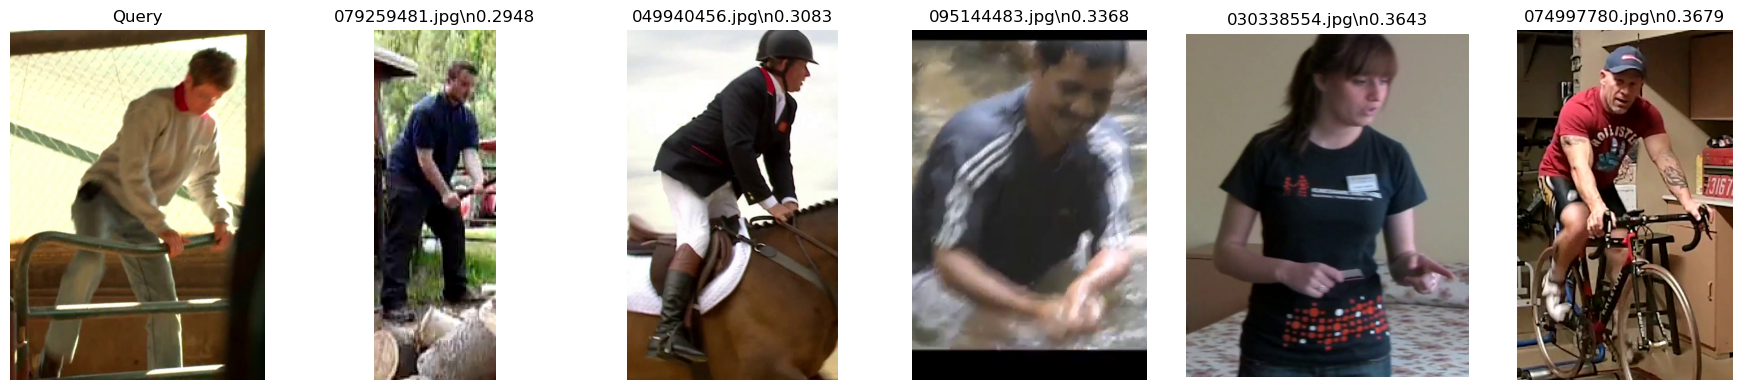

In [27]:
neighbors = find_nearest_neighbors(
    dataset,
    query_file=file,
    k=5
)

show_neighbors(
    query_file=file,
    neighbors=neighbors,
    image_dir=f"{path}/mpii_human_pose_v1/images",
    dataset=dataset,
    k=5
)